In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv('spotify_clean.csv')
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,popularity_tier,length_category
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,High,Long
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,High,Normal
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,High,Long
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,High,Normal
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,Very High,Normal


Text(0, 0.5, 'Number of Songs')

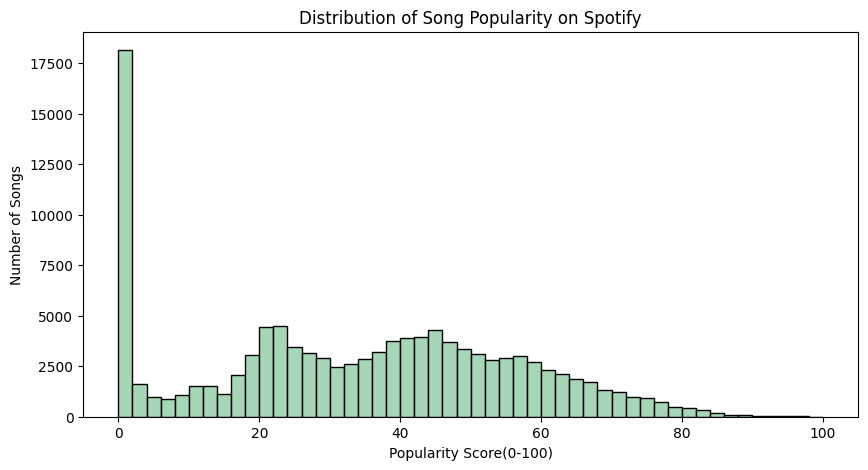

In [5]:
plt.figure(figsize=(10,5))
plt.hist(df['popularity'], bins=50, color="#98D1ACDE", edgecolor='black')
plt.title('Distribution of Song Popularity on Spotify')
plt.xlabel('Popularity Score(0-100)')
plt.ylabel('Number of Songs')

In [6]:
df_active=df[df['popularity']>0]
print(f"Removed {len(df)-len(df_active)} songs with 0 popularity")
print(f"Remaining: {len(df_active)} songs")

Removed 16019 songs with 0 popularity
Remaining: 97980 songs


Text(0, 0.5, 'Number of Songs')

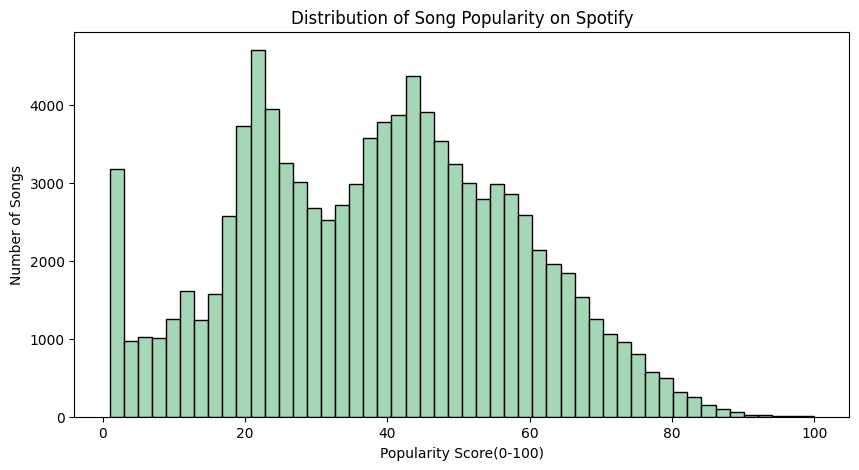

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df_active['popularity'], bins=50, color="#98D1ACDE", edgecolor='black')
plt.title('Distribution of Song Popularity on Spotify')
plt.xlabel('Popularity Score(0-100)')
plt.ylabel('Number of Songs')

Text(0, 0.5, 'Genre')

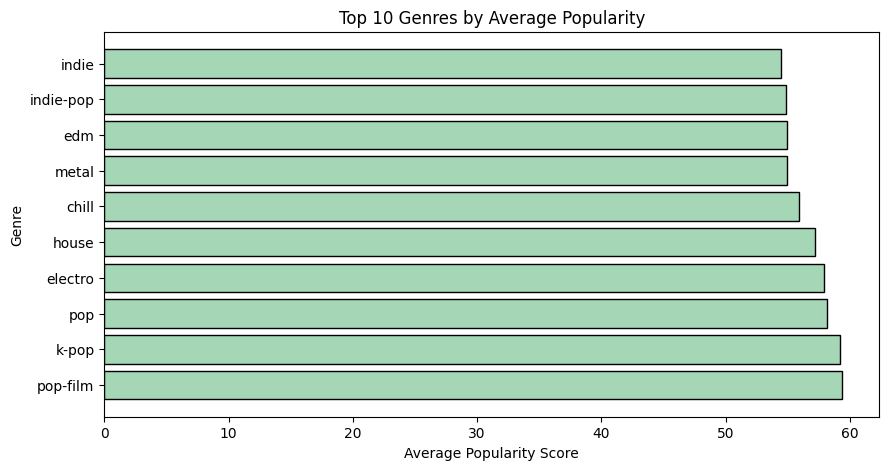

In [8]:
top_genres=df_active.groupby('track_genre')['popularity'].mean().nlargest(10).reset_index()

plt.figure(figsize=(10,5))
plt.barh(top_genres['track_genre'], top_genres['popularity'], color="#98D1ACDE", edgecolor='black')
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')

([<matplotlib.axis.XTick at 0x118307550>,
 [Text(0, 0, 'Non-Explicit'), Text(1, 0, 'Explicit')])

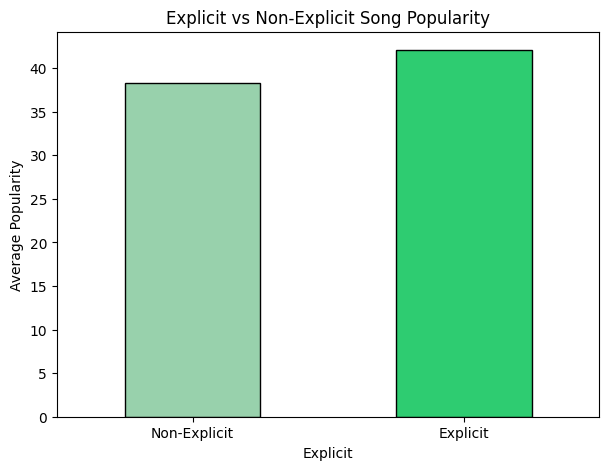

In [9]:
plt.figure(figsize=(7,5))
df_active.groupby('explicit')['popularity'].mean().plot(kind='bar', color=['#98D1AC', '#2ECC71'], edgecolor='black')
plt.title('Explicit vs Non-Explicit Song Popularity')
plt.xlabel('Explicit')
plt.ylabel('Average Popularity')
plt.xticks([0,1], ['Non-Explicit', 'Explicit'], rotation=0)

Text(0, 0.5, 'Popularity Score')

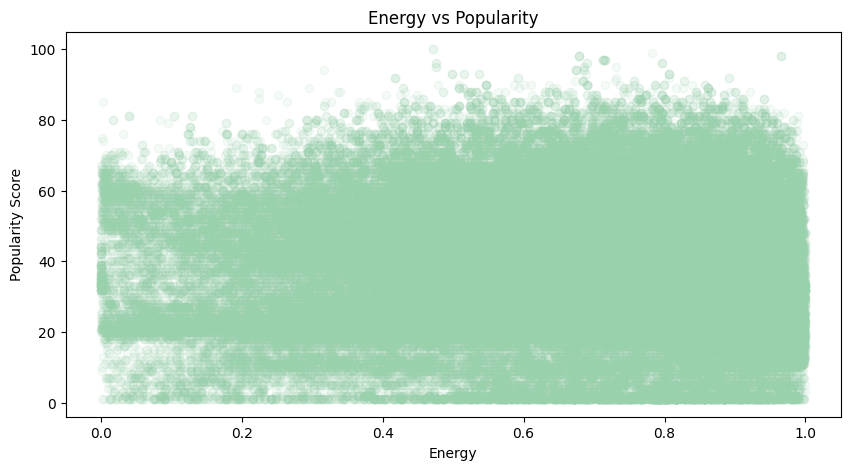

In [10]:
plt.figure(figsize=(10,5))
plt.scatter(df_active['energy'], df_active['popularity'], alpha=0.1, color='#98D1AC')
plt.title('Energy vs Popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity Score')

Text(0, 0.5, 'Popularity Score')

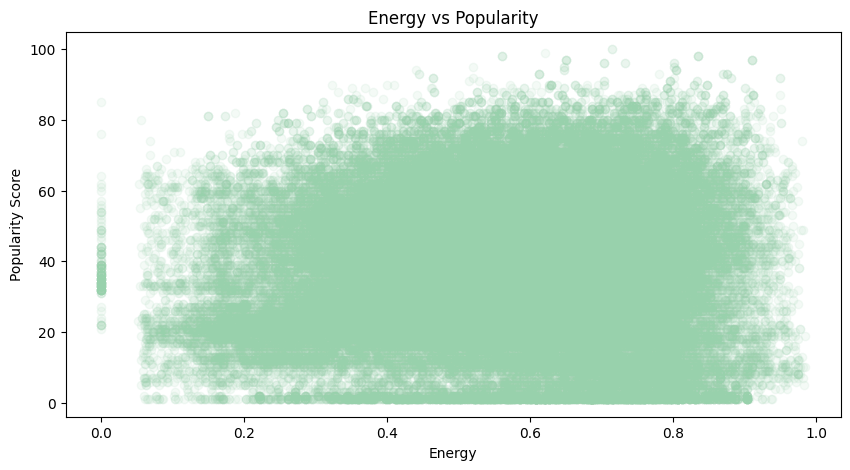

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(df_active['danceability'], df_active['popularity'], alpha=0.1, color='#98D1AC')
plt.title('Energy vs Popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity Score')

Text(0, 0.5, 'Average Popularity')

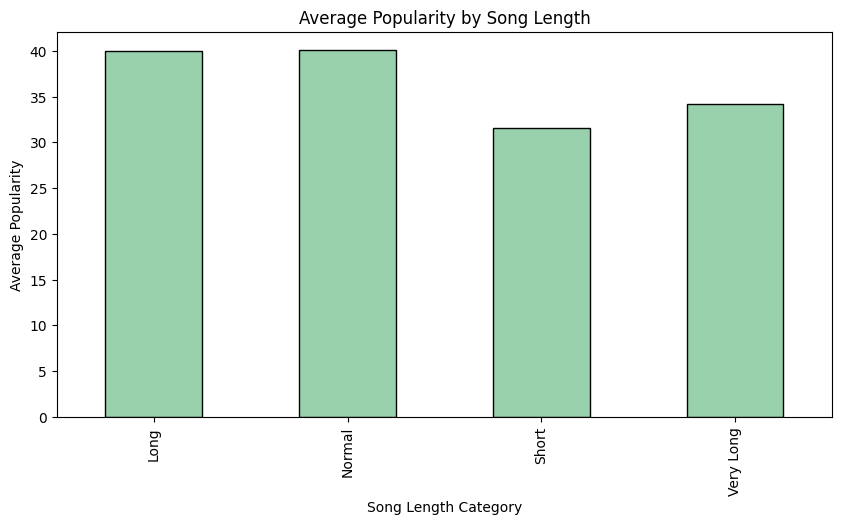

In [12]:
plt.figure(figsize=(10,5))
df_active.groupby('length_category')['popularity'].mean().plot(kind='bar', color='#98D1AC', edgecolor='black')
plt.title('Average Popularity by Song Length')
plt.xlabel('Song Length Category')
plt.ylabel('Average Popularity')

Text(0.5, 1.0, 'Correlation Heatmap of Audio Features')

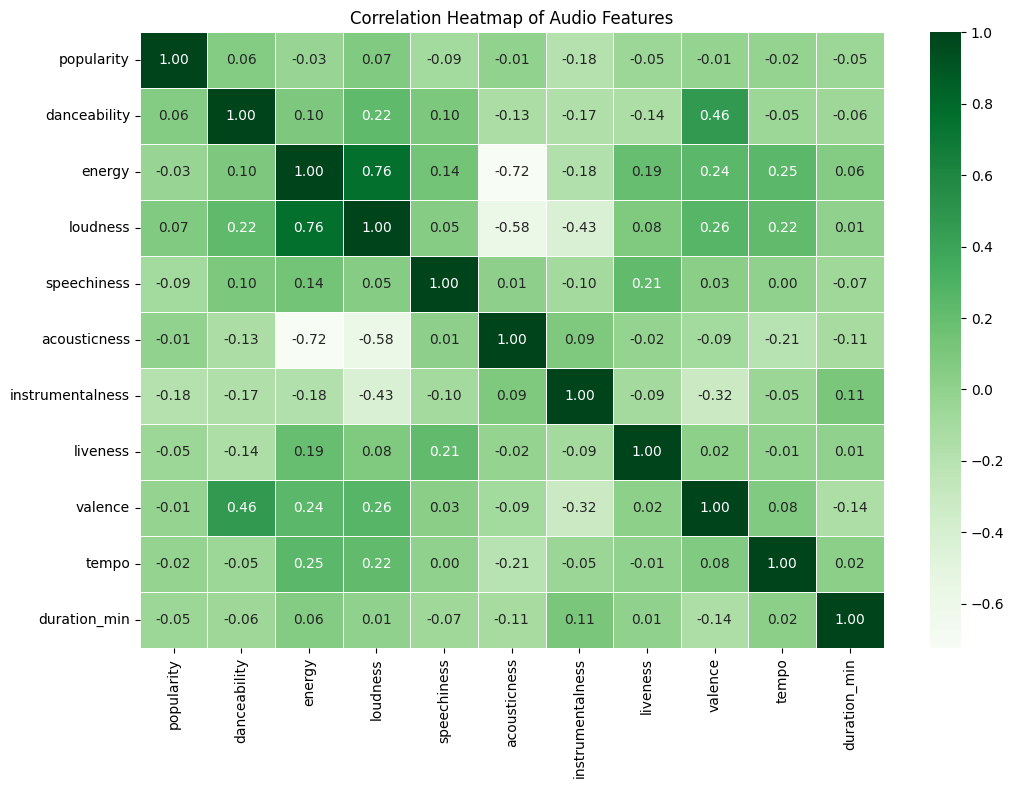

In [13]:
plt.figure(figsize=(12,8))
corr_cols = ['popularity', 'danceability', 'energy', 'loudness', 
             'speechiness', 'acousticness', 'instrumentalness', 
             'liveness', 'valence', 'tempo', 'duration_min']

sns.heatmap(df_active[corr_cols].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='Greens',
            linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features')

In [14]:
df_active.to_csv('spotify_clean_active.csv', index=False)